# Notebook 5: Graph Analytics

In the previous notebook, we compared naive RAG and Graph RAG on individual queries and found that Graph RAG outperformed naive RAG on 5 out of 6 test questions. Now let's analyze the knowledge graph itself to answer three practical questions about the curriculum:

**Which topics hold the curriculum together?** In a course catalog, some topics act as bridges between different areas, connecting robotics to cognitive science or machine learning to healthcare. The identification of these bridging topics can help curriculum designers spot dependencies and also help students plan learning paths across subfields.

**Which courses cover similar ground?** If a student finishes one course, which others have the most topic overlap? Structural similarity based on shared topics captures relationships that text search misses: two courses can use very different language in their descriptions but cover the same areas.

**What natural groupings exist in the curriculum?** Courses tend to cluster around shared specializations. Discovering these clusters helps programs identify their strengths, spot gaps, and build coherent tracks or prerequisites.

We answer these questions using three graph algorithms: centrality, similarity, and community detection. All analyses work with child-level topics, excluding those that appear in every course (AI, Machine Learning, Computer Science), since they cannot distinguish one course from another.

---
## Setup

In [1]:
import os
import pandas as pd
import numpy as np
import networkx as nx
from community import community_louvain
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

from dotenv import load_dotenv
from neo4j import GraphDatabase

load_dotenv(dotenv_path='../.env')
PROJECT_ROOT = Path('..')

plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_colwidth', None)

In [2]:
NEO4J_URI = os.getenv('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER = os.getenv('NEO4J_USER', 'neo4j')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD', '')

if not NEO4J_PASSWORD:
    raise ValueError('NEO4J_PASSWORD not set.')

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

with driver.session() as session:
    result = session.run('RETURN 1 AS connected')
    print(f'Neo4j connected: {result.single()["connected"] == 1}')

Neo4j connected: True


---
## Pull graph data from Neo4j

First we extract child-level topics per course and the RELATED_TO co-occurrence edges between them. Parent-level categories (Engineering, Data Science Analytics & Computer Technology, etc.) are automatically excluded by the Cypher query, since they are not tagged as `level: 'child'`.

In [3]:
# Courses with their child-level topics
result = driver.execute_query('''
    MATCH (c:Course)-[:HAS_TOPIC]->(t:Topic {level: 'child'})
    RETURN c.title AS course, c.year AS year, collect(t.name) AS topics
''')
course_data = {r['course']: {'topics': r['topics'], 'year': r['year']} for r in result.records}

# RELATED_TO edges between child topics
result = driver.execute_query('''
    MATCH (t1:Topic {level: 'child'})-[r:RELATED_TO]->(t2:Topic {level: 'child'})
    RETURN t1.name AS source, t2.name AS target, r.weight AS weight
''')
related_edges = [(r['source'], r['target'], r['weight']) for r in result.records]

print(f'{len(course_data)} courses, {len(related_edges)} RELATED_TO edges')

50 courses, 161 RELATED_TO edges


In [4]:
# Identify and filter ubiquitous child topics (topics present in >= 90% of courses)
topic_freq = Counter()
for data in course_data.values():
    for t in data['topics']:
        topic_freq[t] += 1

ubiquitous = {t for t, count in topic_freq.items() if count >= len(course_data) * 0.9}
print(f'Ubiquitous child topics (filtered): {ubiquitous}')

# Filtered course-topic mapping
course_topics = {
    course: [t for t in data['topics'] if t not in ubiquitous]
    for course, data in course_data.items()
}

n_distinctive = [len(ts) for ts in course_topics.values()]
print(f'Distinctive topics per course: min={min(n_distinctive)}, '
      f'max={max(n_distinctive)}, mean={np.mean(n_distinctive):.1f}')

# Courses with no distinctive topics
general_courses = sorted([c for c, ts in course_topics.items() if len(ts) == 0])
if general_courses:
    print(f'{len(general_courses)} courses have only ubiquitous topics: {", ".join(general_courses)}')

Ubiquitous child topics (filtered): {'AI', 'Computer Science', 'Machine Learning'}
Distinctive topics per course: min=0, max=6, mean=1.9
4 courses have only ubiquitous topics: AI 101, Advances in Computer Vision, Foundation Models and Generative AI, How to AI (Almost) Anything


---
## 1. Which topics hold the curriculum together?

Some topics appear in many courses and connect different areas of the curriculum. Others are specialized, appearing only in a few closely related courses. To tell them apart, let's compute three centrality metrics on the topic co-occurrence graph (RELATED_TO edges, excluding ubiquitous topics):

**Degree centrality** counts direct connections. A topic with high degree co-occurs with many other topics.

**Betweenness centrality** measures how often a topic lies on the shortest path between other topics. High betweenness means that the topic bridges otherwise disconnected parts of the curriculum. If you removed it, some parts of the curriculum would lose their connection to other parts.

**PageRank** identifies topics that are connected to other well-connected topics. A topic ranks highly not just for having many connections, but for being connected to topics that are themselves central. It rewards being embedded in a densely connected part of the network rather than at the periphery.

In [5]:
# Build topic-topic graph from RELATED_TO edges
topic_graph = nx.Graph()
for source, target, weight in related_edges:
    if source not in ubiquitous and target not in ubiquitous:
        topic_graph.add_edge(source, target, weight=weight)

print(f'Topic graph: {topic_graph.number_of_nodes()} nodes, '
      f'{topic_graph.number_of_edges()} edges')

Topic graph: 31 nodes, 65 edges


In [6]:
# Compute centrality metrics
degree = nx.degree_centrality(topic_graph)
betweenness = nx.betweenness_centrality(topic_graph, weight='weight')
pagerank = nx.pagerank(topic_graph, weight='weight')

centrality_df = pd.DataFrame({
    'topic': list(topic_graph.nodes()),
    'degree': [round(degree[n], 3) for n in topic_graph.nodes()],
    'betweenness': [round(betweenness[n], 3) for n in topic_graph.nodes()],
    'pagerank': [round(pagerank[n], 3) for n in topic_graph.nodes()],
    'courses': [topic_freq[n] for n in topic_graph.nodes()],
})
centrality_df = centrality_df.sort_values('pagerank', ascending=False).reset_index(drop=True)
centrality_df

,topic,degree,betweenness,pagerank,courses
0,Cognitive Science,0.367,0.158,0.085,11
1,Electrical Engineering,0.333,0.203,0.077,12
2,Algorithms and Data Structures,0.267,0.132,0.066,8
3,Biology,0.300,0.181,0.045,2
4,Software Design and Engineering,0.167,0.059,0.043,5
5,Data Science,0.200,0.166,0.039,3
6,Systems Engineering,0.200,0.015,0.039,3
7,Biomedical Technologies,0.200,0.111,0.038,3
8,Philosophy,0.233,0.038,0.036,5
9,Psychology,0.167,0.011,0.035,3


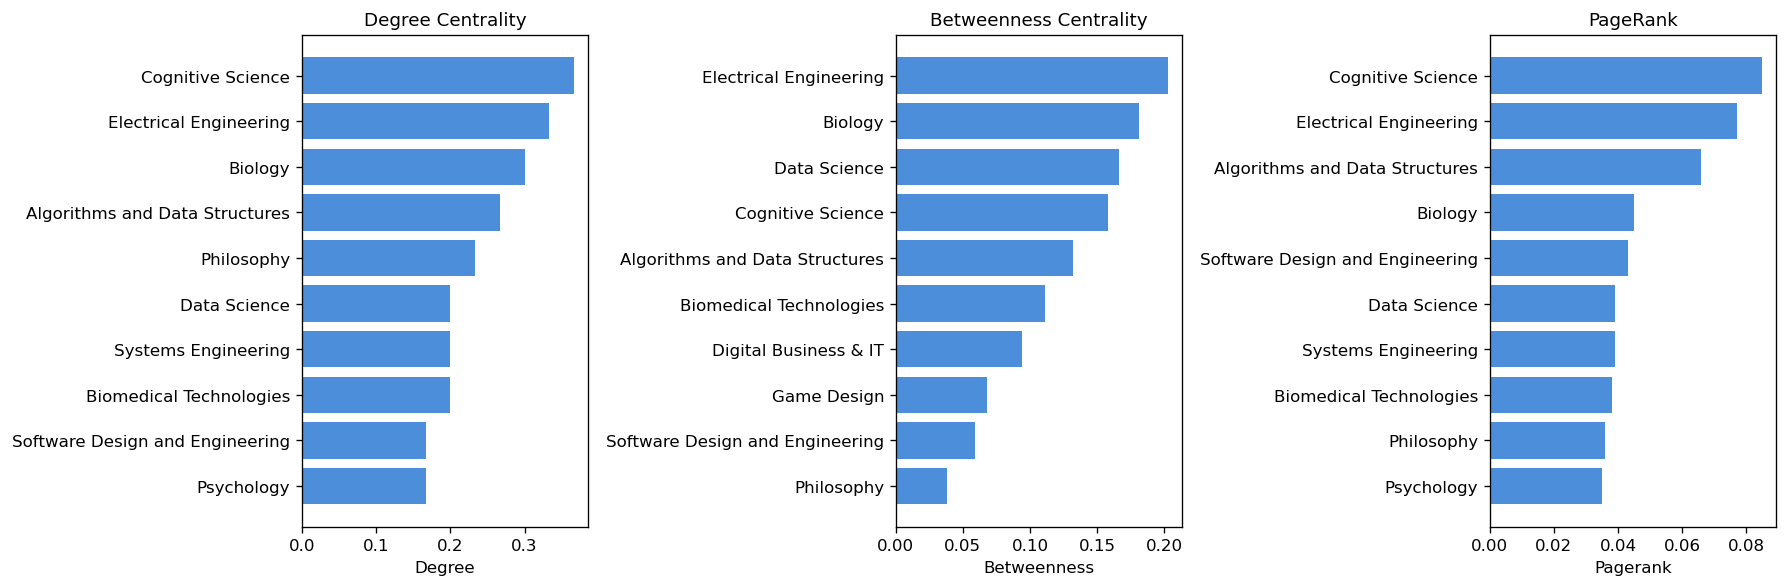

In [7]:
# Top topics by each metric
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['degree', 'betweenness', 'pagerank']
titles = ['Degree Centrality', 'Betweenness Centrality', 'PageRank']

for ax, metric, title in zip(axes, metrics, titles):
    top = centrality_df.nlargest(10, metric)
    ax.barh(top['topic'], top[metric], color='#4C8EDA')
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel(metric.capitalize())

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures' / 'topic_centrality.png', bbox_inches='tight')
plt.show()

In [8]:
# What do the top central topics connect to?
print('Neighbors of the top 5 topics by PageRank (weight = co-occurrence count):')
print()
top5 = centrality_df.head(5)['topic'].tolist()
for topic in top5:
    neighbors = []
    for n in topic_graph.neighbors(topic):
        w = topic_graph[topic][n]['weight']
        neighbors.append((n, w))
    neighbors.sort(key=lambda x: -x[1])
    neighbor_str = ', '.join(f'{n} (weight: {w})' for n, w in neighbors[:8])
    print(f'{topic}: {neighbor_str}')

Neighbors of the top 5 topics by PageRank (weight = co-occurrence count):

Cognitive Science: Algorithms and Data Structures (weight: 4), Psychology (weight: 3), Mathematics (weight: 2), Electrical Engineering (weight: 2), Biomedical Technologies (weight: 1), Systems Engineering (weight: 1), Linguistics (weight: 1), Systems Thinking (weight: 1)
Electrical Engineering: Software Design and Engineering (weight: 3), Cognitive Science (weight: 2), Systems Engineering (weight: 2), Mechanical Engineering (weight: 2), Algorithms and Data Structures (weight: 1), Biomedical Technologies (weight: 1), Game Design (weight: 1), Media Studies (weight: 1)
Algorithms and Data Structures: Cognitive Science (weight: 4), Mathematics (weight: 3), Systems Engineering (weight: 2), Data Science (weight: 1), Mechanical Engineering (weight: 1), Electrical Engineering (weight: 1), Systems Thinking (weight: 1), Economics (weight: 1)
Biology: Biomedical Technologies (weight: 1), Cognitive Science (weight: 1), Clim

---
The three metrics tell different stories about the same graph.

**Cognitive Science** leads in degree centrality and PageRank: it co-occurs with the widest range of other topics (from Psychology to Electrical Engineering), and those neighbors are themselves well-connected. For a student building an interdisciplinary profile, Cognitive Science is the single topic that touches the most subfields.

**Electrical Engineering** leads in betweenness centrality: it sits on more shortest paths than any other topic. It is related to topics like Software Design and Engineering, Systems Engineering, Mechanical Engineering, Game Design, and Media Studies. Some of these topics don't co-occur with each other directly. If you remove Electrical Engineering from the graph, several of those connections disappear.

**Biology** is the most surprising result. It appears in only 2 courses, yet it has the second-highest betweenness (0.181). Its neighbor list explains this: it connects to Biomedical Technologies, Cognitive Science, Climate Science, Electrical Engineering, Policy and Administration, Psychology, Energy, and Philosophy. These are topics spread across multiple clusters, and Biology is the only path between some of them. This makes it a critical bridge despite its low course count. A curriculum designer looking to strengthen cross-disciplinary connections would want to add more Biology-related courses.

At the other end, topics like Faculty Leadership, Visualization, Pedagogy and Curriculum, and Aerospace Engineering have zero betweenness. They connect only within their own cluster. This isn't necessarily a problem, but it means they represent isolated specializations with no topical pathway to the rest of the curriculum.

---
## 2. Which courses cover similar ground?

Jaccard similarity measures the overlap between two sets. For two courses A and B, it is the number of shared non-ubiquitous child topics divided by the total number of distinct topics across both courses:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

A score of 1.0 means identical topic sets. A score of 0 means no overlap. We require at least 2 shared topics to consider a pair meaningfully similar, since sharing a single topic is weak evidence of real overlap.

In [9]:
# Compute Jaccard similarity for all course pairs (min 2 shared topics)
courses = list(course_topics.keys())
similarity_pairs = []

for i in range(len(courses)):
    for j in range(i + 1, len(courses)):
        a = set(course_topics[courses[i]])
        b = set(course_topics[courses[j]])
        intersection = a & b
        if len(intersection) < 2:
            continue
        union = a | b
        jaccard = len(intersection) / len(union)
        similarity_pairs.append({
            'course_a': courses[i],
            'course_b': courses[j],
            'jaccard': round(jaccard, 3),
            'shared': ', '.join(sorted(intersection)),
            'n_shared': len(intersection),
        })

sim_df = pd.DataFrame(similarity_pairs).sort_values('jaccard', ascending=False).reset_index(drop=True)
print(f'{len(sim_df)} course pairs with >= 2 shared distinctive topics')
sim_df

19 course pairs with >= 2 shared distinctive topics


,course_a,course_b,jaccard,shared,n_shared
0,Autonomous Robot Design Competition,Introduction to Electrical Engineering and Computer Science I,1.000,"Electrical Engineering, Software Design and Engineering",2
1,Machine Learning,Statistical Learning Theory and Applications,1.000,"Algorithms and Data Structures, Cognitive Science, Mathematics",3
2,Affective Computing,Minds and Machines,0.667,"Cognitive Science, Psychology",2
3,Machine Learning,Techniques in Artificial Intelligence (SMA 5504),0.667,"Algorithms and Data Structures, Cognitive Science",2
4,Robocraft Programming Competition,Introduction to Electrical Engineering and Computer Science I,0.667,"Electrical Engineering, Software Design and Engineering",2
5,Statistical Learning Theory and Applications,Techniques in Artificial Intelligence (SMA 5504),0.667,"Algorithms and Data Structures, Cognitive Science",2
6,Robocraft Programming Competition,Autonomous Robot Design Competition,0.667,"Electrical Engineering, Software Design and Engineering",2
7,Medical Artificial Intelligence,Medical Decision Support,0.667,"Biological Engineering, Biomedical Technologies",2
8,"Identification, Estimation, and Learning",Mobile Autonomous Systems Laboratory,0.500,"Electrical Engineering, Mechanical Engineering",2
9,Machine Learning,Mathematics of Machine Learning,0.500,"Algorithms and Data Structures, Mathematics",2


Out of 1,225 possible course pairs, only 19 share at least 2 distinctive topics. The histogram below shows how those 19 pairs are distributed: most cluster around Jaccard 0.5 to 0.7, with two pairs reaching 1.0 (identical distinctive topic sets). This means that meaningful course recommendations based on topic overlap can be concentrated in a small subset of the catalog. A recommendation system built on this similarity would surface a focused, manageable set of suggestions rather than overwhelming students with loosely related options.

Looking at the table, a few patterns stand out. The two pairs with Jaccard = 1.0 have identical distinctive topics, but they are not redundant. *Machine Learning* and *Statistical Learning Theory* share Algorithms and Data Structures, Cognitive Science, and Mathematics, but they probably have a different approach. These are the strongest "if you liked X, try Y" candidates in the catalog.

The pairs clustering around 0.667 reveal topical neighborhoods: both *Affective Computing* and *Minds and Machines* cover Cognitive Science and Psychology; the robotics competition courses share Electrical Engineering and Software Design; the two medical courses share Biological Engineering and Biomedical Technologies. Each of these groupings represents a coherent subfield where students are likely to move between courses.

The lowest-scoring pair (Jaccard = 0.286, *Identification, Estimation, and Learning* and *Principles of Autonomy and Decision Making*) shares only 2 topics out of 7 combined. This is the boundary of what we consider meaningful overlap. Below this, the connection becomes too thin to support a useful recommendation.

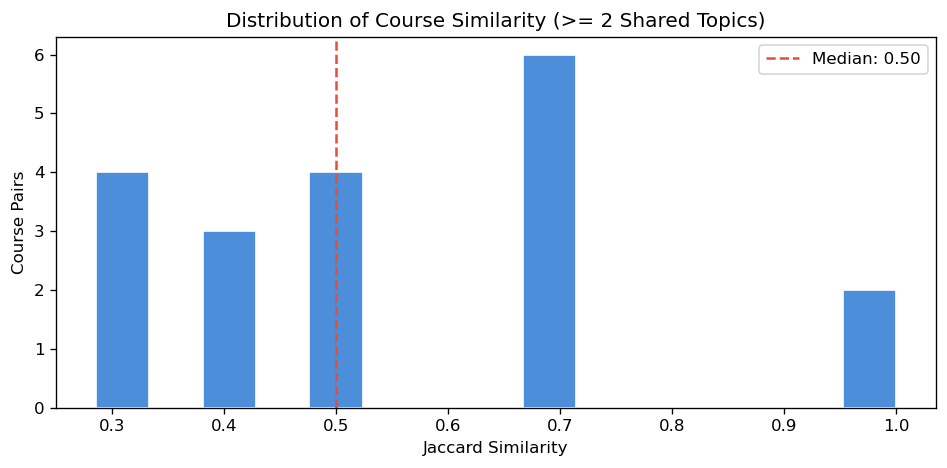

In [10]:
# Similarity distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sim_df['jaccard'], bins=15, color='#4C8EDA', edgecolor='white')
ax.set_xlabel('Jaccard Similarity')
ax.set_ylabel('Course Pairs')
ax.set_title('Distribution of Course Similarity (>= 2 Shared Topics)')
ax.axvline(sim_df['jaccard'].median(), color='#E74C3C', linestyle='--',
           label=f'Median: {sim_df["jaccard"].median():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures' / 'similarity_distribution.png', bbox_inches='tight')
plt.show()

---
## 3. What natural groupings exist?

The objective of community detection is to find clusters of courses that are more connected to each other than to the rest of the graph. I built a course-course graph where edges represent shared non-ubiquitous child topics (weighted by count). Then, I applied the Louvain algorithm, which optimizes modularity—a measure of how cleanly the network is divided into distinct groups.

Four courses have only ubiquitous topics (AI, Machine Learning, and Computer Science). Without distinctive features, they don't fit into any community and are reported as "Not clustered."

In [11]:
# Build course-course graph (only courses with distinctive topics)
course_graph = nx.Graph()
courses_with_topics = [c for c in courses if len(course_topics[c]) > 0]

for i in range(len(courses_with_topics)):
    for j in range(i + 1, len(courses_with_topics)):
        shared = set(course_topics[courses_with_topics[i]]) & set(course_topics[courses_with_topics[j]])
        if shared:
            course_graph.add_edge(courses_with_topics[i], courses_with_topics[j], weight=len(shared))

for c in courses_with_topics:
    if c not in course_graph:
        course_graph.add_node(c)

print(f'Course graph: {course_graph.number_of_nodes()} nodes, '
      f'{course_graph.number_of_edges()} edges')
print(f'{len(general_courses)} courses excluded (no distinctive topics)')

Course graph: 46 nodes, 188 edges
4 courses excluded (no distinctive topics)


In [12]:
# Louvain community detection
partition = community_louvain.best_partition(
    course_graph, weight='weight', resolution=0.8, random_state=42
)
n_communities = len(set(partition.values()))
modularity = community_louvain.modularity(partition, course_graph, weight='weight')

print(f'{n_communities} communities (modularity: {modularity:.3f})')

7 communities (modularity: 0.414)


In [13]:
# Name communities by their dominant topics
community_members = {}
for course, comm_id in partition.items():
    community_members.setdefault(comm_id, []).append(course)

community_names = {}
for comm_id, members in community_members.items():
    topic_counts = Counter()
    for course in members:
        for t in course_topics[course]:
            topic_counts[t] += 1
    if topic_counts:
        top = [t for t, _ in topic_counts.most_common(2)]
        community_names[comm_id] = ' / '.join(top)
    else:
        community_names[comm_id] = 'Uncategorized'

# Print community summary
print(f'{n_communities} course communities detected:\n')
for comm_id in sorted(community_members.keys()):
    name = community_names[comm_id]
    print(f'  {name} ({len(community_members[comm_id])} courses)')

if general_courses:
    print(f'  Not clustered ({len(general_courses)} courses)')

7 course communities detected:

  Visualization / Aerospace Engineering (3 courses)
  Electrical Engineering / Software Design and Engineering (14 courses)
  Philosophy / Climate Science (4 courses)
  Media Studies / User Experience (3 courses)
  Pedagogy and Curriculum / Faculty Leadership (4 courses)
  Digital Business & IT / Data Science (5 courses)
  Cognitive Science / Algorithms and Data Structures (13 courses)
  Not clustered (4 courses)


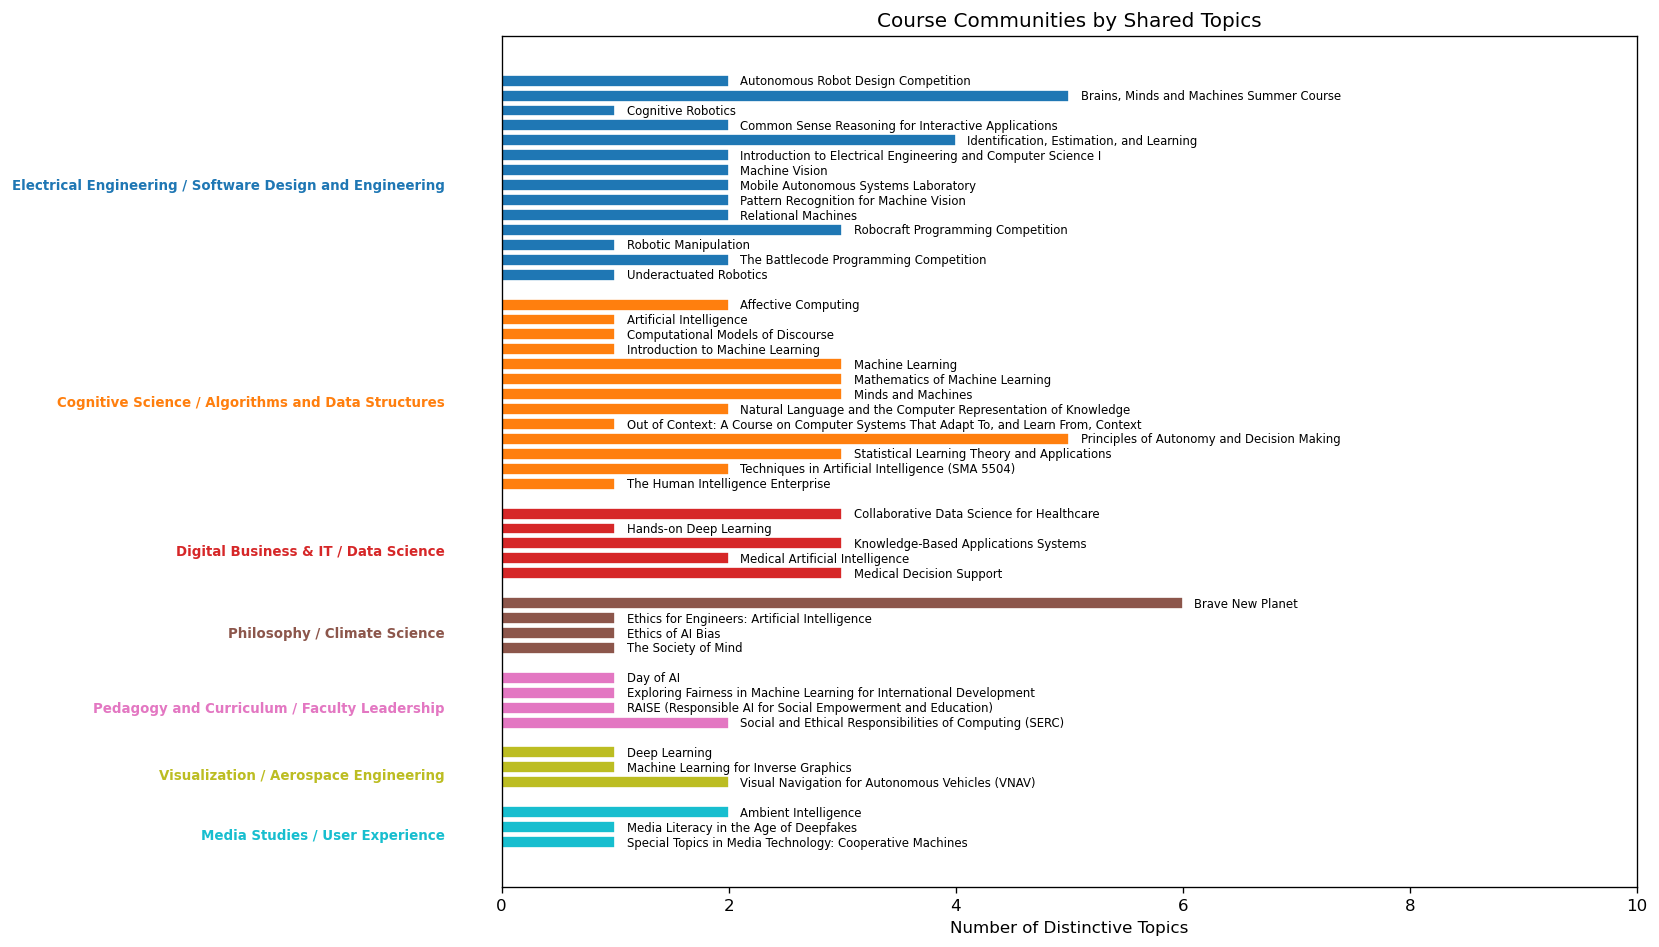

In [14]:
# Community visualization: grouped bar chart
fig, ax = plt.subplots(figsize=(14, 8))

# Sort communities by size
sorted_comms = sorted(community_members.keys(),
                      key=lambda c: len(community_members[c]), reverse=True)

cmap = plt.cm.tab10
y_offset = 0
y_ticks = []
y_labels = []
comm_colors = {}

for idx, comm_id in enumerate(sorted_comms):
    members = sorted(community_members[comm_id])
    name = community_names[comm_id]
    color = cmap(idx / max(len(sorted_comms) - 1, 1))
    comm_colors[comm_id] = color

    for course in members:
        n_topics = len(course_topics.get(course, []))
        ax.barh(y_offset, n_topics, color=color, edgecolor='white', height=0.8)
        ax.text(n_topics + 0.1, y_offset, course, va='center', fontsize=7)
        y_ticks.append(y_offset)
        y_offset += 1

    # Add community label
    mid = y_offset - len(members) / 2
    ax.text(-0.5, mid, name, va='center', ha='right', fontsize=8, fontweight='bold',
            color=color)
    y_offset += 1  # gap between communities

ax.set_xlabel('Number of Distinctive Topics')
ax.set_yticks([])
ax.invert_yaxis()
ax.set_title('Course Communities by Shared Topics', fontsize=12)
ax.set_xlim(0, max(len(ts) for ts in course_topics.values()) + 4)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures' / 'course_communities.png', bbox_inches='tight')
plt.show()

In [15]:
# Close connection
driver.close()
print('Connection closed')

Connection closed


The chart shows each community with its courses, ordered by size. The bar length represents how many distinctive topics each course has. Courses with more topics tend to sit at the intersection of multiple subfields and connect their community to others.

The four courses excluded from clustering (*AI 101*, *Advances in Computer Vision*, *Foundation Models and Generative AI*, and *How to AI (Almost) Anything*) have only ubiquitous topics. In order to classify these courses in the appropriate community, more specific topic tags should be added to them.

---
## Future Work

This project focused on comparing naive RAG against Graph RAG. The system works and the results are clear, but there are several strategies that could improve it further.

**Retrieval quality:** The current BM25 tokenizer uses regex word splitting with no stemming or stopword removal. A proper NLP tokenizer would improve keyword matching, using spaCy or NLTK, for example.

**Evaluation depth:** The current evaluation uses set intersection to compute recall. Standard IR metrics would give a more complete picture: Precision@K and Recall@K at different cutoffs, Mean Reciprocal Rank (MRR) for ranking quality, and Normalized Discounted Cumulative Gain (NDCG) for graded relevance. The ground truth file could also be expanded with more questions and validated with multiple annotators to measure inter-annotator agreement.

**Advanced RAG techniques:** The current pipeline uses a single retrieval step followed by LLM generation. Production RAG systems often improve on this with query rewriting (reformulating the user's question before retrieval) and re-ranking (using a cross-encoder to rescore retrieved documents), among other strategies.

**Graph enrichment:** The knowledge graph currently relies on MIT's existing topic tags. The use of NLP techniques to extract entities from course descriptions (like NER or relation extraction models) could add finer-grained topics or relationships that don't exist in the original metadata. This would enrich the graph and make the analytics more informative.

**Scalability:** With 50 courses, every operation is fast. With hundreds or thousands of courses, the system could benefit from Neo4j's built-in vector index for retrieval, a full-text index on instructor names to replace the current label scan, and pagination in the Cypher templates. The UNWIND batching pattern used in Notebook 3 already follows the right approach for bulk ingestion.

---
## Summary

This project is a brief demonstration of what becomes possible when course data is organized as a knowledge graph rather than a flat file.

**Centrality** revealed that Cognitive Science and Electrical Engineering are the backbone of the curriculum. Cognitive Science connects the widest range of subfields. Electrical Engineering sits on the most shortest paths between clusters. Biology, despite appearing in only 2 courses, bridges clusters that would otherwise be disconnected. A curriculum designer could use these findings to identify which topics have a central position and where new courses could strengthen weak cross-disciplinary connections.

**Similarity** found that only 19 out of 1,225 possible course pairs share enough distinctive topics to be considered structurally related. This tight set illustrates how a recommendation feature could work: when a student finishes one course, the similarity table reveals a focused list of structurally related alternatives that text search alone could miss.

**Community detection** identified potential specialization tracks. These clusters can inform program design, student advising, and catalog organization. The 4 unclustered courses (those with only ubiquitous topics) highlight a metadata gap: adding more specific topic tags would allow them to be placed in the right community.

Together with the RAG comparison in Notebook 4, these results confirm what motivated this project: structuring data as a knowledge graph reveals capabilities that flat text retrieval cannot match. From the same 50-course dataset, the graph enabled instructor traversals, corpus-wide co-occurrence analysis, structural similarity, and community detection.

Graphs don't just store data. They encode meaning. And when the question requires meaning beyond keywords, Graph RAG makes the difference.

In my next project, I'll use the same dataset to build a knowledge graph with **RDF**, **OWL**, and **SPARQL**: a head-to-head between property graphs and the semantic web stack. Spoiler alert: both are fascinating! See you next time.